#**Entrega 2. Desarrollo.**

##**Descripción de la tarea**

La **entrega 2**, debe contener:

- La explicación de la gestión del equipo de trabajo, hipótesis, fuentes de información adicional y benchmark, timing del proyecto.
- El desarrollo de un modelo descriptivo con las técnicas y algoritmos de los módulos vistos, incluyendo el quinto módulo.

Criterios de evaluación:

- Establecimiento de hipótesis y planteamientos sobre el tema del TFM correctamente relacionadas con los objetivos:
  - Creatividad e innovación en las medidas planteadas.
  - Contribución, solución adoptada y viabilidad.
- Amplitud del benchmark realizado y adecuación de las fuentes consultadas.
- Establecimiento de unos hitos temporales mínimos de trabajo para la solución de la necesidad.
- Se incluye la estimación de los costes de la solución que se propone y se detalla la repercusión o retorno que puede aportar.
- Desarrollo de un modelo predictivo, para lo cual se podrán usar las técnicas vistas en los módulos 4 y 5.

##**Librerías**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install pysal
import pysal.lib as lib
import geopandas as gpd
import esda
import libpysal as lps
import spreg
import requests
from io import BytesIO
from libpysal.weights import KNN, DistanceBand
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import networkx as nx
from google.colab import files

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.4/132.4 kB 11.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.0/59.0 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.3/141.3 kB 8.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.9/47.9 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.0/278.0 kB 12.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 346.9/346.9 kB 16.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 12.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━

##**Datos**

In [ ]:
#Declaramos el url donde se encuentra la base de datos
##Datos sin medias de airbnbs
url = 'https://raw.githubusercontent.com/brunopless/TFM-Equipo-4-BDDS/main/df_final_no_media_aribnb.csv'

#Cargamos el archivo en un dataframe
df = pd.read_csv(url)

#Nos quedamos sólo con los de barcelona
df = df[df['province'] == 'Barcelona']
df = df[df['municipality'] == 'Barcelona']

#Vemos el número de observaciones
df.shape

(3908, 55)

In [ ]:
#Vemos los NAs
df.isna().sum()

index                         0
propertyCode                  0
thumbnail                     8
externalReference           506
numPhotos                     0
floor                      2159
price                         0
priceInfo                     0
propertyType                  0
operation                     0
size                          0
rooms                         0
bathrooms                     0
address                       0
province                      0
municipality                  0
district                      0
country                       0
neighborhood                  0
latitude                      0
longitude                     0
showAddress                   0
url                           0
distance                      0
description                   1
hasVideo                      0
status                        0
newDevelopment                0
hasLift                    1150
parkingSpace               3347
priceByArea                   0
detailed

In [ ]:
#Vamos a lidiar con los datos faltantes
##Para los faltantes de rooms y bathrooms usamos la media como substitución
df['rooms'] = df['rooms'].fillna(df['rooms'].mean())
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].mean())

##Para los NAs de status usamos la clase mayoritaria
majority_status = df['status'].mode()[0]
df['status'] = df['status'].fillna(majority_status)

##Para newdevelopment, topNewDevelopment, hasLift, isParkingSpaceIncludedInPrice y exterior usamos false
df['exterior'] = df['exterior'].fillna(False)
df['newDevelopment'] = df['newDevelopment'].fillna(False)
df['topNewDevelopment'] = df['topNewDevelopment'].fillna(False)
df['hasLift'] = df['hasLift'].fillna(False)

##Para floor utilizaremos 0
df['floor'] = df['floor'].fillna(0)

#Eliminamos algunas columnas redundantes
df = df.drop(columns=['index', 'address', 'province', 'municipality', 'district', 'country', 'neighborhood', "propertyCode", "thumbnail", "externalReference", "numPhotos", "priceInfo", "url",
                      "distance", "description", "hasVideo", "priceByArea", "detailedType", "suggestedTexts", "hasPlan", "has3DTour", "has360", "hasStaging", "topPlus", "highlight", "parkingSpace",
                      "newDevelopmentFinished", "exterior"])

#Vemos los NAs
df.isna().sum()

floor                      0
price                      0
propertyType               0
operation                  0
size                       0
rooms                      0
bathrooms                  0
latitude                   0
longitude                  0
showAddress                0
status                     0
newDevelopment             0
hasLift                    0
topNewDevelopment          0
num_bancos_500             0
num_starbucks_500          0
num_atractivos_500         0
num_buenasmigas_500        0
num_clubesnocturnos_500    0
num_mcdonalds_500          0
num_metro_500              0
num_parking_500            0
num_parkingbici_500        0
num_parques_500            0
num_santagloria_500        0
num_vivari_500             0
num_airbnbs_500            0
dtype: int64

In [ ]:
#Vemos el tipo de dato de cada variable
df.dtypes

floor                       object
price                        int64
propertyType                object
operation                   object
size                       float64
rooms                        int64
bathrooms                    int64
latitude                   float64
longitude                  float64
showAddress                   bool
status                      object
newDevelopment                bool
hasLift                       bool
topNewDevelopment             bool
num_bancos_500               int64
num_starbucks_500            int64
num_atractivos_500           int64
num_buenasmigas_500          int64
num_clubesnocturnos_500      int64
num_mcdonalds_500            int64
num_metro_500                int64
num_parking_500              int64
num_parkingbici_500          int64
num_parques_500              int64
num_santagloria_500          int64
num_vivari_500               int64
num_airbnbs_500              int64
dtype: object

In [ ]:
#Vamos a ver por qué precio es de tipo object
valores_no_numericos = df.loc[pd.to_numeric(df["price"], errors='coerce').isna(), "price"]

print(valores_no_numericos)

Series([], Name: price, dtype: int64)


In [ ]:
#Cambiamos esa observación y el tipo de datos
df.loc[pd.to_numeric(df["price"], errors='coerce').isna(), "price"] = 1390
print(df.iloc[154])

df['price'] = df['price'].astype(float)
print(df['price'].dtypes)

floor                              1
price                           1250
propertyType                    flat
operation                       rent
size                            54.0
rooms                              2
bathrooms                          1
latitude                   41.373873
longitude                   2.169915
showAddress                    False
status                          good
newDevelopment                 False
hasLift                         True
topNewDevelopment              False
num_bancos_500                     6
num_starbucks_500                  0
num_atractivos_500                 2
num_buenasmigas_500                0
num_clubesnocturnos_500            4
num_mcdonalds_500                  1
num_metro_500                      3
num_parking_500                   10
num_parkingbici_500               10
num_parques_500                   10
num_santagloria_500                0
num_vivari_500                     1
num_airbnbs_500                  704
N

In [ ]:
#Vamos a ver cada valor único de cada columna de tipo object
for col in df.select_dtypes(include=['object']).columns:
    print(f"Valores distintos en la columna '{col}':")
    print(df[col].unique())
    print("\n")

Valores distintos en la columna 'floor':
[0 '7' '8' '5' '6' '1' 'en' 'bj' '3' '4' '2' '10' '9' '12' '14' 'st' '11'
 'ss']


Valores distintos en la columna 'propertyType':
['flat' 'duplex' 'penthouse' 'chalet' 'studio']


Valores distintos en la columna 'operation':
['rent']


Valores distintos en la columna 'status':
['good' 'newdevelopment' 'renew']




In [ ]:
#Vamos a corregir la variable floor
##Vamos a cambiar bj y ss por 0, en por 1 y st por -1
df['floor'] = df['floor'].replace(['bj', 'ss', 'en', 'st'], [0, 0, 1, -1])

##Vamos a eliminar las observaciones con el piso 60 y cambiarlas por la media, ya que ningún edificio departamental
##de Barcelona tiene 60 pisos
df['floor'] = pd.to_numeric(df['floor'], errors='coerce')
mean_floor = df[df['floor'] != 60]['floor'].mean()
df['floor'] = df['floor'].replace(60, int(round(mean_floor)))
df['floor'] = df['floor'].astype(int, errors='ignore')
df['floor'] = df['floor'].astype(int)

print(df['floor'].unique())
print(df['floor'].dtypes)

[ 0  7  8  5  6  1  3  4  2 10  9 12 14 -1 11]
int64


In [ ]:
#Cambiamos 'goood' por 'good' en status
df['status'] = df['status'].replace('goood', 'good')

print(df['status'].unique())

['good' 'newdevelopment' 'renew']


In [ ]:
#Vamos a cambiar los valores de hasLift de 'True' a True y de 'False' y ' ' a False
df['hasLift'] = df['hasLift'].replace('True', True)
df['hasLift'] = df['hasLift'].replace('False', False)
df['hasLift'] = df['hasLift'].replace(' ', False)

df['hasLift'] = df['hasLift'].astype(bool)

print(df['hasLift'].unique())
print(df['hasLift'].dtypes)

[False  True]
bool


In [ ]:
#Para la variable topNewDevelopment vamos a cambiar 'False' por False y 'True', "{'groupDescription': 'Destacado'}"
#y {'groupDescription': 'Top'}" por True
df['topNewDevelopment'] = df['topNewDevelopment'].replace('False', False)
df['topNewDevelopment'] = df['topNewDevelopment'].replace('True', True)
df['topNewDevelopment'] = df['topNewDevelopment'].replace("{'groupDescription': 'Destacado'}", True)
df['topNewDevelopment'] = df['topNewDevelopment'].replace("{'groupDescription': 'Top'}", True)

df['topNewDevelopment'] = df['topNewDevelopment'].astype(bool)

print(df['topNewDevelopment'].unique())
print(df['topNewDevelopment'].dtypes)

[False]
bool


In [ ]:
#Vamos a cambiar el tipo de rooms y bathrooms a int
df['rooms'] = df['rooms'].astype(int)
df['bathrooms'] = df['bathrooms'].astype(int)

print(df['rooms'].unique())
print(df['bathrooms'].unique())
print(df['rooms'].dtypes)
print(df['bathrooms'].dtypes)

[ 3  4  2  5  1  7  8  0  6  9 40 10]
[ 1  2  3  4  5  8  6 10  7  9]
int64
int64


In [ ]:
df.dtypes

floor                        int64
price                      float64
propertyType                object
operation                   object
size                       float64
rooms                        int64
bathrooms                    int64
latitude                   float64
longitude                  float64
showAddress                   bool
status                      object
newDevelopment                bool
hasLift                       bool
topNewDevelopment             bool
num_bancos_500               int64
num_starbucks_500            int64
num_atractivos_500           int64
num_buenasmigas_500          int64
num_clubesnocturnos_500      int64
num_mcdonalds_500            int64
num_metro_500                int64
num_parking_500              int64
num_parkingbici_500          int64
num_parques_500              int64
num_santagloria_500          int64
num_vivari_500               int64
num_airbnbs_500              int64
dtype: object

In [ ]:
df.shape

(3908, 26)

###Renta

In [ ]:
#Seleccionamos a los datos de renta
renta = df[df['operation'] == 'rent']
renta = renta.drop(columns=['operation'])

#Normalizamos las variables de tipo int y float con respecto al máximo
num_cols = renta.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.difference(['latitude', 'longitude', 'price'])
renta[num_cols] = renta[num_cols].apply(lambda x: x / x.max())


#Utilizamos el método one-shot con las variables de tipo object
renta = pd.get_dummies(renta, columns=['status', 'newDevelopment', 'topNewDevelopment', 'propertyType'], drop_first= True)

#Cambiamos las variables booleanas a 1s y 0s menos el precio
bool_cols = renta.select_dtypes(include=['bool']).columns
renta[bool_cols] = renta[bool_cols].astype(int)

#Nos quedamos con los datos que estén en el cuantil 97.5 de precio
renta = renta[renta['price'] <= renta['price'].quantile(0.975)]

renta.shape

(3812, 29)

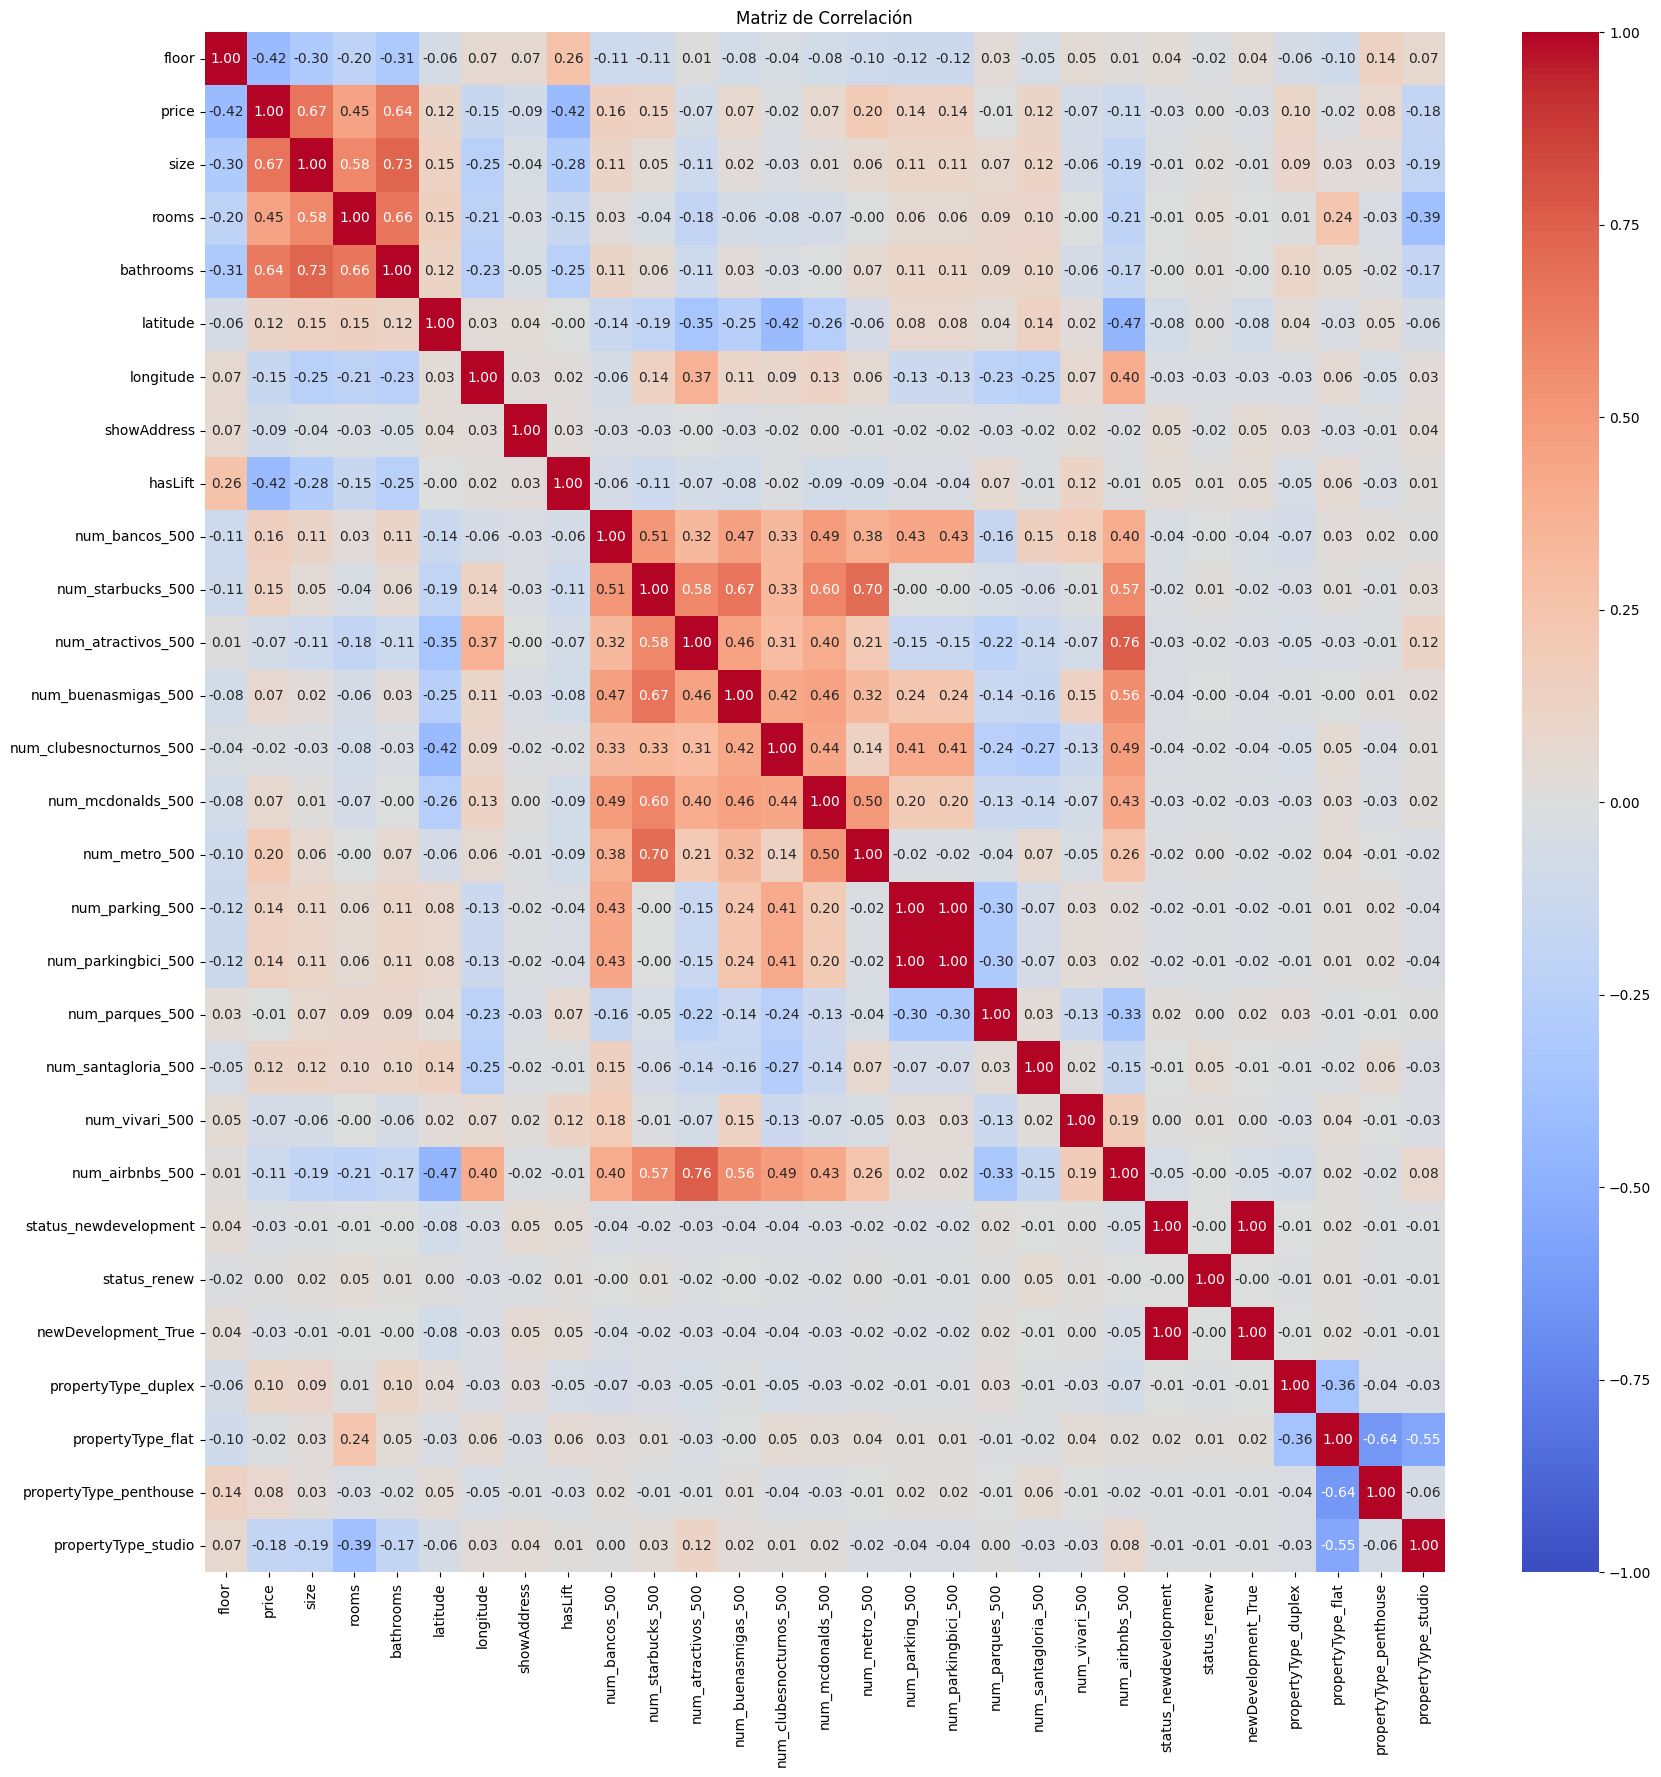

In [ ]:
#Por último, veamos la matriz de correlación
corr_matrix = renta.corr()

plt.figure(figsize=(20, 20))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")

plt.title('Matriz de Correlación')

plt.show()

###Renta y estimación a partir de la venta

In [ ]:
sale = df[df['operation'] == 'sale']

sale = sale.drop(columns=['operation'])
sale['price'] = sale['price'] * 0.01305913 #Estimación conseguida en R de la renta a partir de la venta.
sale['status'] = sale['status'].fillna(majority_status)

##Para newdevelopment, topNewDevelopment, hasLift, isParkingSpaceIncludedInPrice y exterior usamos false
sale['newDevelopment'] = sale['newDevelopment'].fillna(False)
sale['topNewDevelopment'] = sale['topNewDevelopment'].fillna(False)

#Utilizamos el método one-shot con las variables de tipo object
sale = pd.get_dummies(sale, columns=['status', 'newDevelopment', 'topNewDevelopment'], drop_first= True)

#Cambiamos las variables booleanas a 1s y 0s menos el precio
bool_cols = sale.select_dtypes(include=['bool']).columns
sale[bool_cols] = sale[bool_cols].astype(int)

sale.shape

(0, 22)

####Unión

In [ ]:
x_sale = sale.drop(columns=['price'])
y_sale = sale['price']

x_train_E2 = pd.concat([x_train, x_sale], ignore_index=True)
y_train_E2 = pd.concat([y_train, y_sale], ignore_index=True)

#Los salvamos
x_train_E2.to_csv('x_train_E2.csv', index=False)
y_train_E2.to_csv('y_train_E2.csv', index=False)

x_train_E2

,floor,size,rooms,bathrooms,latitude,longitude,showAddress,hasLift,num_bancos_500,num_starbucks_500,...,num_metro_500,num_parking_500,num_parkingbici_500,num_parques_500,num_santagloria_500,num_vivari_500,num_airbnbs_500,status_newdevelopment,status_renew,newDevelopment_True
0,0.071429,0.023952,0.025,0.1,41.398082,2.122645,0,1,0.100000,0.000000,...,0.047619,0.058140,0.058140,0.652174,1.0,0.0,0.025347,0.0,0.0,0.0
1,0.000000,0.050898,0.050,0.2,41.384321,2.184430,0,1,0.200000,0.000000,...,0.071429,0.093023,0.093023,0.086957,0.0,0.0,0.497888,0.0,0.0,0.0
2,0.000000,0.149701,0.125,0.5,41.420535,2.191955,0,1,0.066667,0.000000,...,0.071429,0.081395,0.081395,0.304348,0.0,0.0,0.039228,0.0,0.0,0.0
3,0.000000,0.040120,0.050,0.1,41.411444,2.156189,0,1,0.200000,0.000000,...,0.000000,0.081395,0.081395,0.086957,0.0,0.0,0.073627,0.0,0.0,0.0
4,0.214286,0.020359,0.050,0.1,41.373833,2.156457,0,1,0.066667,0.000000,...,0.023810,0.116279,0.116279,0.217391,0.0,0.0,0.297526,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2663,0.000000,0.140120,0.075,0.3,41.394836,2.159828,0,0,0.566667,0.333333,...,0.071429,0.325581,0.325581,0.130435,0.0,0.0,0.452625,0.0,0.0,0.0
2664,0.000000,0.107784,0.100,0.3,41.405011,2.140489,0,1,0.200000,0.000000,...,0.047619,0.093023,0.093023,0.217391,0.5,0.0,0.125528,0.0,0.0,0.0
2665,0.000000,0.095808,0.100,0.2,41.379274,2.150289,0,1,0.333333,0.000000,...,0.071429,0.069767,0.069767,0.130435,0.0,0.2,0.368739,0.0,0.0,0.0
2666,0.000000,0.116766,0.100,0.2,41.383804,2.176870,0,0,0.566667,0.500000,...,0.047619,0.011628,0.011628,0.130435,0.0,0.2,0.996379,0.0,0.0,0.0
